In [8]:
# import pandas as pd
# import numpy as np
# import statsmodels.formula.api as smf
# import matplotlib.pyplot as plt
# import seaborn as sns
# import warnings
# from matplotlib.ticker import FixedLocator

# # Suppress technical warnings
# warnings.simplefilter(action='ignore', category=FutureWarning)
# warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)

# # --- LOAD DATA ---
# file_path = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_kg_ha_updated.xlsx"
# df = pd.read_excel(file_path)

# # Standardize column names
# df.columns = df.columns.str.strip()
# column_map = {'Corrected_Yield': 'CorrectedYield', 'Uncorrected_Yield': 'UncorrectedYield'}
# df = df.rename(columns=column_map)

# # Factor casting
# for col in ['ENTRY', 'REP', 'IBLK', 'Experiment Name']:
#     if col in df.columns:
#         df[col] = df[col].astype('category')

# results = []

# # --- CALCULATION ---
# for exp_name, group_data in df.groupby('Experiment Name', observed=False):
#     if len(group_data) < 10: 
#         continue
    
#     trial_stats = {'Experiment': str(exp_name)}
#     valid_trial = True
    
#     for trait in ['UncorrectedYield', 'CorrectedYield']:
#         analysis_data = group_data.copy().dropna(subset=[trait])
#         if analysis_data.empty: 
#             valid_trial = False
#             continue
        
#         try:
#             fixed_parts = ["C(ENTRY)"]
#             if analysis_data['REP'].nunique() > 1:
#                 fixed_parts.append("C(REP)")
#             formula = f"Q('{trait}') ~ " + " + ".join(fixed_parts)
            
#             try:
#                 model = smf.mixedlm(formula, analysis_data, groups=analysis_data["REP"], re_formula="~0 + C(IBLK)")
#                 result = model.fit(method=["lbfgs"], maxiter=10000)
#                 mse = result.scale 
#             except:
#                 ols_formula = f"Q('{trait}') ~ C(ENTRY) + C(REP)" if analysis_data['REP'].nunique() > 1 else f"Q('{trait}') ~ C(ENTRY)"
#                 ols_res = smf.ols(ols_formula, data=analysis_data).fit()
#                 mse = ols_res.mse_resid
            
#             trial_stats[f'{trait}_Mean'] = analysis_data[trait].mean()
#             trial_stats[f'{trait}_RMSE'] = np.sqrt(mse)
            
#         except Exception:
#             valid_trial = False
    
#     # Only add if all 4 metrics were successfully calculated and are finite
#     if valid_trial and len(trial_stats) == 5:
#         if all(np.isfinite(list(trial_stats.values())[1:])):
#             results.append(trial_stats)

# # --- VISUALIZATION ---
# plot_df = pd.DataFrame(results)

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
# sns.set_theme(style="white")

# # Panel 1: Mean Comparison
# ax1.barh(plot_df['Experiment'], -plot_df['UncorrectedYield_Mean'], color='steelblue', label='Uncorrected Mean')
# ax1.barh(plot_df['Experiment'], plot_df['CorrectedYield_Mean'], color='seagreen', label='Corrected Mean')
# ax1.axvline(0, color='black', lw=1.5)
# ax1.set_title("Mean Yield Comparison", fontsize=14, pad=15)
# ax1.set_xlabel("Yield (kg/ha)")

# # Panel 2: RMSE Comparison
# ax2.barh(plot_df['Experiment'], -plot_df['UncorrectedYield_RMSE'], color='indianred', label='Uncorrected RMSE')
# ax2.barh(plot_df['Experiment'], plot_df['CorrectedYield_RMSE'], color='goldenrod', label='Corrected RMSE')
# ax2.axvline(0, color='black', lw=1.5)
# ax2.set_title("RMSE Comparison (Precision)", fontsize=14, pad=15)
# ax2.set_xlabel("RMSE (kg/ha)")

# # Adding numeric labels with finite check
# for i, row in plot_df.iterrows():
#     # Helper to check if value is plot-able
#     def is_valid(v): return v is not None and np.isfinite(v) and v != 0

#     if is_valid(row['UncorrectedYield_Mean']):
#         ax1.text(-row['UncorrectedYield_Mean']/2, i, f"{row['UncorrectedYield_Mean']:.0f}", ha='center', va='center', color='white', weight='bold')
#     if is_valid(row['CorrectedYield_Mean']):
#         ax1.text(row['CorrectedYield_Mean']/2, i, f"{row['CorrectedYield_Mean']:.0f}", ha='center', va='center', color='white', weight='bold')
    
#     if is_valid(row['UncorrectedYield_RMSE']):
#         ax2.text(-row['UncorrectedYield_RMSE']/2, i, f"{row['UncorrectedYield_RMSE']:.1f}", ha='center', va='center', color='white', weight='bold')
#     if is_valid(row['CorrectedYield_RMSE']):
#         ax2.text(row['CorrectedYield_RMSE']/2, i, f"{row['CorrectedYield_RMSE']:.1f}", ha='center', va='center', color='white', weight='bold')

# # Correctly setting ticks to avoid UserWarning
# for ax in [ax1, ax2]:
#     ticks = ax.get_xticks()
#     ax.xaxis.set_major_locator(FixedLocator(ticks))
#     ax.set_xticklabels([f"{abs(x):.0f}" for x in ticks])
#     ax.legend(loc='upper right', frameon=True)

# plt.tight_layout()
# plt.savefig('Fixed_Tornado_Comparison.png', dpi=300)
# plt.show()

# print(f"Plotting complete. Processed {len(plot_df)} trials successfully.")

In [5]:
# import pandas as pd
# import numpy as np
# import statsmodels.formula.api as smf
# import matplotlib.pyplot as plt
# import seaborn as sns
# import warnings
# from matplotlib.ticker import FixedLocator

# # Suppress technical warnings
# warnings.simplefilter(action='ignore', category=FutureWarning)
# warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)

# # --- LOAD DATA ---
# file_path = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_kg_ha_updated.xlsx"
# df = pd.read_excel(file_path)

# # Standardize column names
# df.columns = df.columns.str.strip()
# column_map = {'Corrected_Yield': 'CorrectedYield', 'Uncorrected_Yield': 'UncorrectedYield'}
# df = df.rename(columns=column_map)

# # Factor casting
# for col in ['ENTRY', 'REP', 'IBLK', 'Experiment Name']:
#     if col in df.columns:
#         df[col] = df[col].astype('category')

# results = []

# # --- CALCULATION ---
# for exp_name, group_data in df.groupby('Experiment Name', observed=False):
#     if len(group_data) < 10: 
#         continue
    
#     trial_stats = {'Experiment': str(exp_name)}
#     valid_trial = True
    
#     for trait in ['UncorrectedYield', 'CorrectedYield']:
#         analysis_data = group_data.copy().dropna(subset=[trait])
#         if analysis_data.empty: 
#             valid_trial = False
#             continue
        
#         try:
#             fixed_parts = ["C(ENTRY)"]
#             if analysis_data['REP'].nunique() > 1:
#                 fixed_parts.append("C(REP)")
#             formula = f"Q('{trait}') ~ " + " + ".join(fixed_parts)
            
#             try:
#                 model = smf.mixedlm(formula, analysis_data, groups=analysis_data["REP"], re_formula="~0 + C(IBLK)")
#                 result = model.fit(method=["lbfgs"], maxiter=10000)
#                 mse = result.scale 
#             except:
#                 ols_formula = f"Q('{trait}') ~ C(ENTRY) + C(REP)" if analysis_data['REP'].nunique() > 1 else f"Q('{trait}') ~ C(ENTRY)"
#                 ols_res = smf.ols(ols_formula, data=analysis_data).fit()
#                 mse = ols_res.mse_resid
            
#             mean_val = analysis_data[trait].mean()
#             rmse_val = np.sqrt(mse)
            
#             trial_stats[f'{trait}_Mean'] = mean_val
#             trial_stats[f'{trait}_RMSE'] = rmse_val
#             trial_stats[f'{trait}_CV'] = (rmse_val / mean_val) * 100
            
#         except Exception:
#             valid_trial = False
    
#     # We now expect 7 items: Experiment name + (Mean, RMSE, CV) * 2 traits
#     if valid_trial and len(trial_stats) == 7:
#         if all(np.isfinite(list(trial_stats.values())[1:])):
#             results.append(trial_stats)

# # --- VISUALIZATION ---
# plot_df = pd.DataFrame(results)

# # Create 3 subplots now
# fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 8), sharey=True)
# sns.set_theme(style="white")

# # Panel 1: Mean Comparison
# ax1.barh(plot_df['Experiment'], -plot_df['UncorrectedYield_Mean'], color='steelblue', label='Uncorrected Mean')
# ax1.barh(plot_df['Experiment'], plot_df['CorrectedYield_Mean'], color='seagreen', label='Corrected Mean')
# ax1.axvline(0, color='black', lw=1.5)
# ax1.set_title("Mean Yield Comparison", fontsize=14, pad=15)
# ax1.set_xlabel("Yield (kg/ha)")

# # Panel 2: RMSE Comparison
# ax2.barh(plot_df['Experiment'], -plot_df['UncorrectedYield_RMSE'], color='indianred', label='Uncorrected RMSE')
# ax2.barh(plot_df['Experiment'], plot_df['CorrectedYield_RMSE'], color='goldenrod', label='Corrected RMSE')
# ax2.axvline(0, color='black', lw=1.5)
# ax2.set_title("RMSE Comparison (Precision)", fontsize=14, pad=15)
# ax2.set_xlabel("RMSE (kg/ha)")

# # Panel 3: CV% Comparison
# ax3.barh(plot_df['Experiment'], -plot_df['UncorrectedYield_CV'], color='purple', label='Uncorrected CV%')
# ax3.barh(plot_df['Experiment'], plot_df['CorrectedYield_CV'], color='mediumorchid', label='Corrected CV%')
# ax3.axvline(0, color='black', lw=1.5)
# ax3.set_title("CV% Comparison", fontsize=14, pad=15)
# ax3.set_xlabel("CV (%)")

# # Helper to check if value is plot-able
# def is_valid(v): return v is not None and np.isfinite(v) and v != 0

# # Adding numeric labels to all panels
# for i, row in plot_df.iterrows():
#     # Mean Labels
#     if is_valid(row['UncorrectedYield_Mean']):
#         ax1.text(-row['UncorrectedYield_Mean']/2, i, f"{row['UncorrectedYield_Mean']:.0f}", ha='center', va='center', color='white', weight='bold')
#     if is_valid(row['CorrectedYield_Mean']):
#         ax1.text(row['CorrectedYield_Mean']/2, i, f"{row['CorrectedYield_Mean']:.0f}", ha='center', va='center', color='white', weight='bold')
    
#     # RMSE Labels
#     if is_valid(row['UncorrectedYield_RMSE']):
#         ax2.text(-row['UncorrectedYield_RMSE']/2, i, f"{row['UncorrectedYield_RMSE']:.1f}", ha='center', va='center', color='white', weight='bold')
#     if is_valid(row['CorrectedYield_RMSE']):
#         ax2.text(row['CorrectedYield_RMSE']/2, i, f"{row['CorrectedYield_RMSE']:.1f}", ha='center', va='center', color='white', weight='bold')
        
#     # CV Labels
#     if is_valid(row['UncorrectedYield_CV']):
#         ax3.text(-row['UncorrectedYield_CV']/2, i, f"{row['UncorrectedYield_CV']:.1f}%", ha='center', va='center', color='white', weight='bold', fontsize=9)
#     if is_valid(row['CorrectedYield_CV']):
#         ax3.text(row['CorrectedYield_CV']/2, i, f"{row['CorrectedYield_CV']:.1f}%", ha='center', va='center', color='white', weight='bold', fontsize=9)

# # Correctly setting ticks for all 3 axes
# for ax in [ax1, ax2, ax3]:
#     ticks = ax.get_xticks()
#     ax.xaxis.set_major_locator(FixedLocator(ticks))
#     ax.set_xticklabels([f"{abs(x):.0f}" for x in ticks])
#     ax.legend(loc='upper right', frameon=True, fontsize=10)

# plt.tight_layout()
# plt.savefig('Triple_Panel_Tornado_Comparison.png', dpi=300)
# plt.show()

# print(f"Plotting complete. Processed {len(plot_df)} trials across three comparison metrics.")

In [ ]:
# compare the cv based on the Uncorrected and Corrected Yield 

C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 3.906087
  warnings.warn(msg, Con

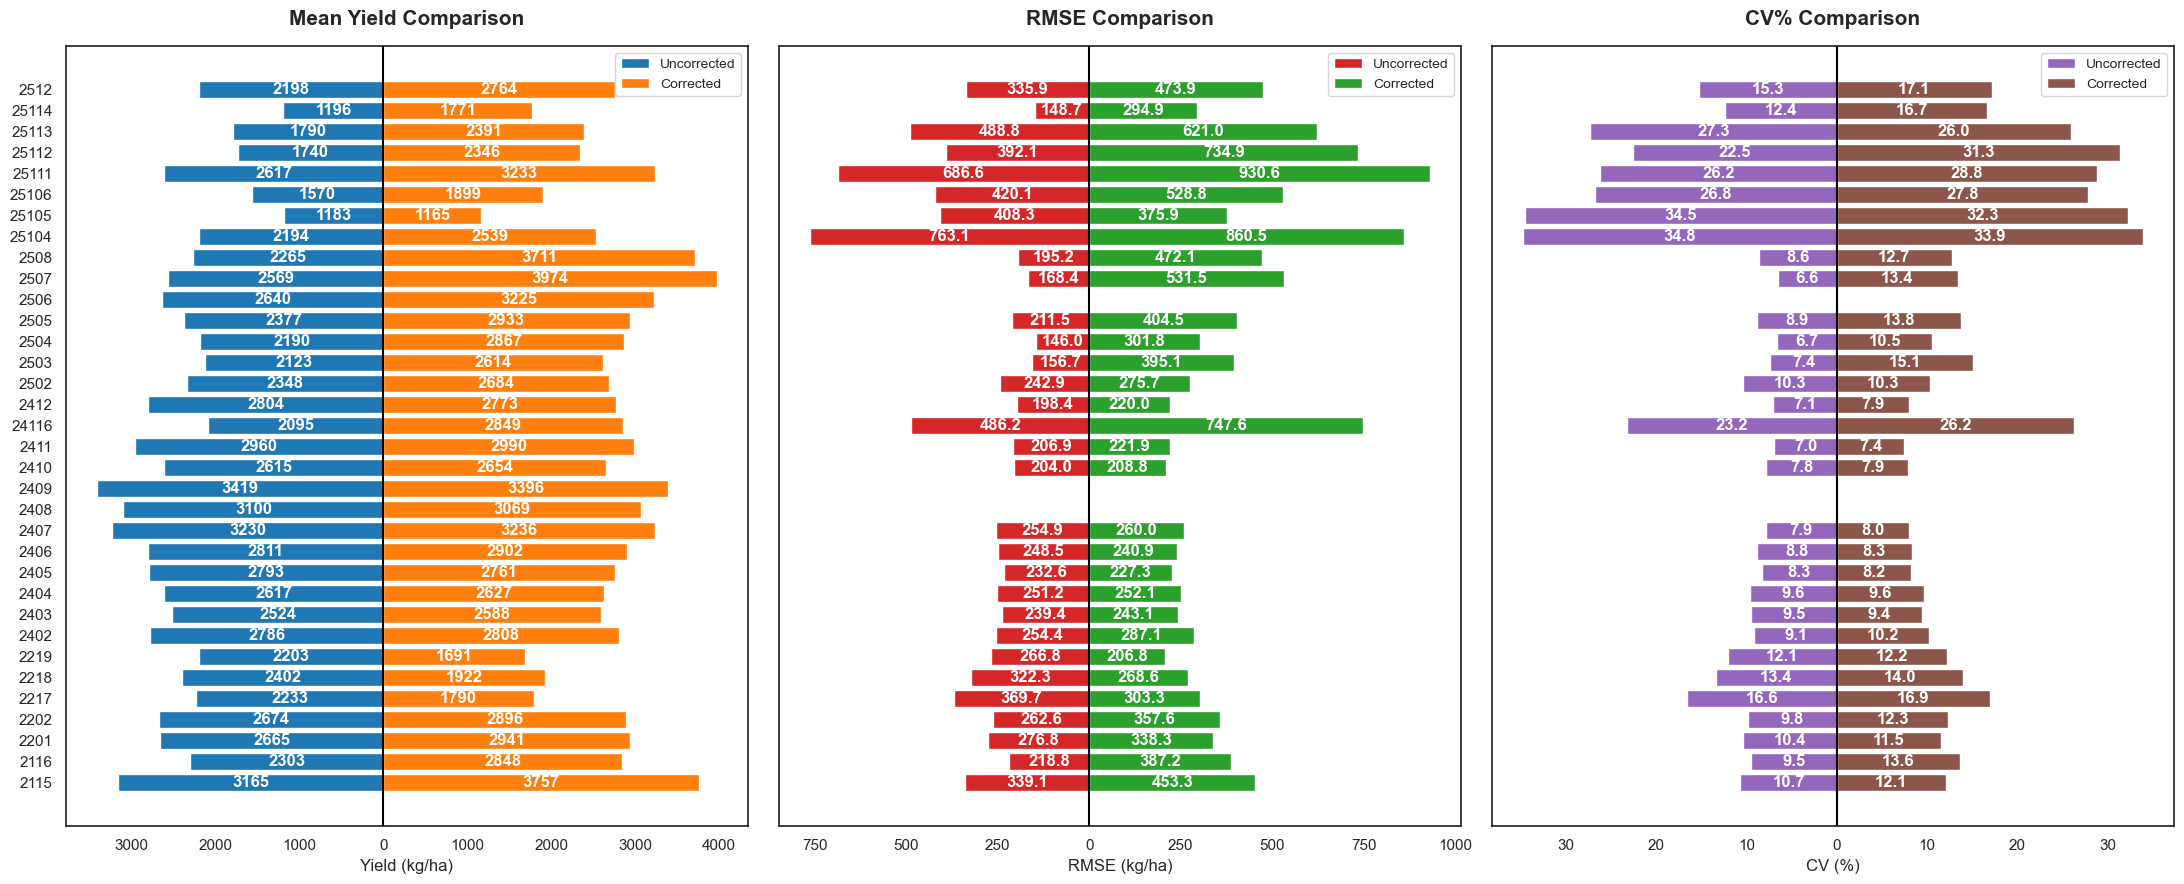

Analysis complete. Metrics for 34 trials calculated and plotted.


In [4]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.ticker import FixedLocator

# Suppress technical warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)

# --- LOAD AND PREPARE DATA ---
file_path = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_kg_ha_updated.xlsx"
df = pd.read_excel(file_path)

# Standardize column names
df.columns = df.columns.str.strip()
df = df.rename(columns={'Corrected_Yield': 'CorrectedYield', 'Uncorrected_Yield': 'UncorrectedYield'})

# Ensure categorical types for factors
for col in ['ENTRY', 'REP', 'IBLK', 'Experiment Name']:
    if col in df.columns:
        df[col] = df[col].astype(str)

def calculate_metrics(data, trait):
    """Calculates Mean, RMSE, and CV using consistent mixed model logic."""
    analysis_data = data.dropna(subset=[trait]).copy()
    if len(analysis_data) < 5: 
        return np.nan, np.nan, np.nan
    
    fixed_parts = ["C(ENTRY)"]
    if analysis_data['REP'].nunique() > 1:
        fixed_parts.append("C(REP)")
    formula = f"Q('{trait}') ~ " + " + ".join(fixed_parts)
    
    try:
        try:
            # Mixed Linear Model
            model = smf.mixedlm(formula, analysis_data, groups=analysis_data["REP"], re_formula="~0 + C(IBLK)")
            result = model.fit(method=["lbfgs"], maxiter=5000)
            mse = result.scale
        except:
            # Fallback to OLS
            ols_formula = f"Q('{trait}') ~ C(ENTRY) + C(REP)" if analysis_data['REP'].nunique() > 1 else f"Q('{trait}') ~ C(ENTRY)"
            ols_result = smf.ols(ols_formula, data=analysis_data).fit()
            mse = ols_result.mse_resid
            
        mean_val = analysis_data[trait].mean()
        rmse_val = np.sqrt(mse)
        cv_val = (rmse_val / mean_val) * 100
        return mean_val, rmse_val, cv_val
    except:
        return np.nan, np.nan, np.nan

# --- CALCULATION LOOP ---
results_list = []
for exp_name, exp_data in df.groupby('Experiment Name'):
    # Calculate for Uncorrected
    u_mean, u_rmse, u_cv = calculate_metrics(exp_data, 'UncorrectedYield')
    # Calculate for Corrected
    c_mean, c_rmse, c_cv = calculate_metrics(exp_data, 'CorrectedYield')
    
    # Only append if we have valid results for both
    if np.isfinite([u_mean, c_mean]).all():
        results_list.append({
            'Trial': exp_name,
            'Uncorrected_Mean': u_mean, 'Corrected_Mean': c_mean,
            'Uncorrected_RMSE': u_rmse, 'Corrected_RMSE': c_rmse,
            'Uncorrected_CV': u_cv, 'Corrected_CV': c_cv
        })

results_df = pd.DataFrame(results_list)

# --- VISUALIZATION (TRIPLE PANEL TORNADO) ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 9), sharey=True)
sns.set_theme(style="white")

def plot_tornado(ax, left_data, right_data, left_label, right_label, title, unit, color_l, color_r, is_int=False):
    ax.barh(results_df['Trial'], -left_data, color=color_l, label=left_label)
    ax.barh(results_df['Trial'], right_data, color=color_r, label=right_label)
    ax.axvline(0, color='black', linewidth=1.5)
    ax.set_title(title, fontsize=15, pad=15, fontweight='bold')
    ax.set_xlabel(unit, fontsize=12)
    
    # Add labels inside bars
    for i, (l, r) in enumerate(zip(left_data, right_data)):
        fmt = ".0f" if is_int else ".1f"
        ax.text(-l/2, i, f"{l:{fmt}}", va='center', ha='center', color='white', fontweight='bold')
        ax.text(r/2, i, f"{r:{fmt}}", va='center', ha='center', color='white', fontweight='bold')
    
    # Fix X-axis ticks to show absolute values
    ticks = ax.get_xticks()
    ax.xaxis.set_major_locator(FixedLocator(ticks))
    ax.set_xticklabels([f"{abs(x):.0f}" for x in ticks])
    ax.legend(loc='upper right', fontsize=10)

# Panel 1: Mean
plot_tornado(ax1, results_df['Uncorrected_Mean'], results_df['Corrected_Mean'], 
             'Uncorrected', 'Corrected', 'Mean Yield Comparison', 'Yield (kg/ha)', 
             '#1f77b4', '#ff7f0e', is_int=True)

# Panel 2: RMSE
plot_tornado(ax2, results_df['Uncorrected_RMSE'], results_df['Corrected_RMSE'], 
             'Uncorrected', 'Corrected', 'RMSE Comparison', 'RMSE (kg/ha)', 
             '#d62728', '#2ca02c')

# Panel 3: CV%
plot_tornado(ax3, results_df['Uncorrected_CV'], results_df['Corrected_CV'], 
             'Uncorrected', 'Corrected', 'CV% Comparison', 'CV (%)', 
             '#9467bd', '#8c564b')

plt.tight_layout()
plt.savefig('Triple_Panel_Consistent_Tornado.png', dpi=300)
plt.show()

print(f"Analysis complete. Metrics for {len(results_df)} trials calculated and plotted.")

In [ ]:
#TypicL cv

In [7]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import warnings
# from matplotlib.ticker import FixedLocator

# # Suppress technical warnings
# warnings.simplefilter(action='ignore', category=FutureWarning)
# warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)

# # --- LOAD DATA ---
# file_path = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_kg_ha_updated.xlsx"
# df = pd.read_excel(file_path)

# # Standardize column names
# df.columns = df.columns.str.strip()

# # --- PRE-PROCESSING ---
# # Calculate GramPerPlant if not already in the sheet
# # Using PLOTWT / Join_Count as per your previous logic
# if 'GramPerPlant' not in df.columns:
#     df['Join_Count'] = df['Join_Count'].replace(0, np.nan)
#     df['GramPerPlant'] = df['PLOTWT'] / df['Join_Count']

# # Clean data
# df = df.dropna(subset=['GramPerPlant', 'Experiment Name'])

# results = []

# # --- CALCULATION ---
# for exp_name, exp_data in df.groupby('Experiment Name'):
#     values = exp_data['GramPerPlant'].values
    
#     if len(values) < 5:
#         continue
        
#     mean_val = np.mean(values)
#     sd_val = np.std(values, ddof=1) # Sample standard deviation
#     cv_val = (sd_val / mean_val) * 100
    
#     results.append({
#         'Experiment': str(exp_name),
#         'Mean': mean_val,
#         'SD': sd_val,
#         'CV': cv_val
#     })

# plot_df = pd.DataFrame(results)

# # --- VISUALIZATION (TRIPLE PANEL TORNADO) ---
# fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 10), sharey=True)
# sns.set_theme(style="white")

# def create_tornado_panel(ax, data, title, xlabel, color, fmt=".1f"):
#     # Plot bars (centered at 0 for tornado effect)
#     # We plot them all on one side to compare trials, 
#     # but use the barh structure for the requested tornado style
#     ax.barh(plot_df['Experiment'], data, color=color, edgecolor='black', alpha=0.8)
#     ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
#     ax.set_xlabel(xlabel, fontsize=12)
    
#     # Add labels on/beside bars
#     for i, val in enumerate(data):
#         ax.text(val/2, i, f"{val:{fmt}}", va='center', ha='center', 
#                 color='black', fontweight='bold', fontsize=10)
    
#     # Grid and axis formatting
#     ax.xaxis.grid(True, linestyle='--', alpha=0.6)
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)

# # Panel 1: Mean
# create_tornado_panel(ax1, plot_df['Mean'], "Mean Gram/Plant", "Mean (g)", "#4682B4")

# # Panel 2: Standard Deviation (SD)
# create_tornado_panel(ax2, plot_df['SD'], "Standard Deviation", "SD (g)", "#CD5C5C")

# # Panel 3: CV%
# create_tornado_panel(ax3, plot_df['CV'], "CV % (SD/Mean)", "CV (%)", "#6A5ACD")

# plt.tight_layout()
# plt.savefig('GramPerPlant_Stats_Tornado.png', dpi=300)
# plt.show()

# print(f"Analysis complete. Statistics calculated for {len(plot_df)} trials.")

In [ ]:
# compare the cv based on the Uncorrected gram/plant (weight /150) and Corrected gram/plant (weight /join_count) 

C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 3.183166
  warnings.warn(msg, Con

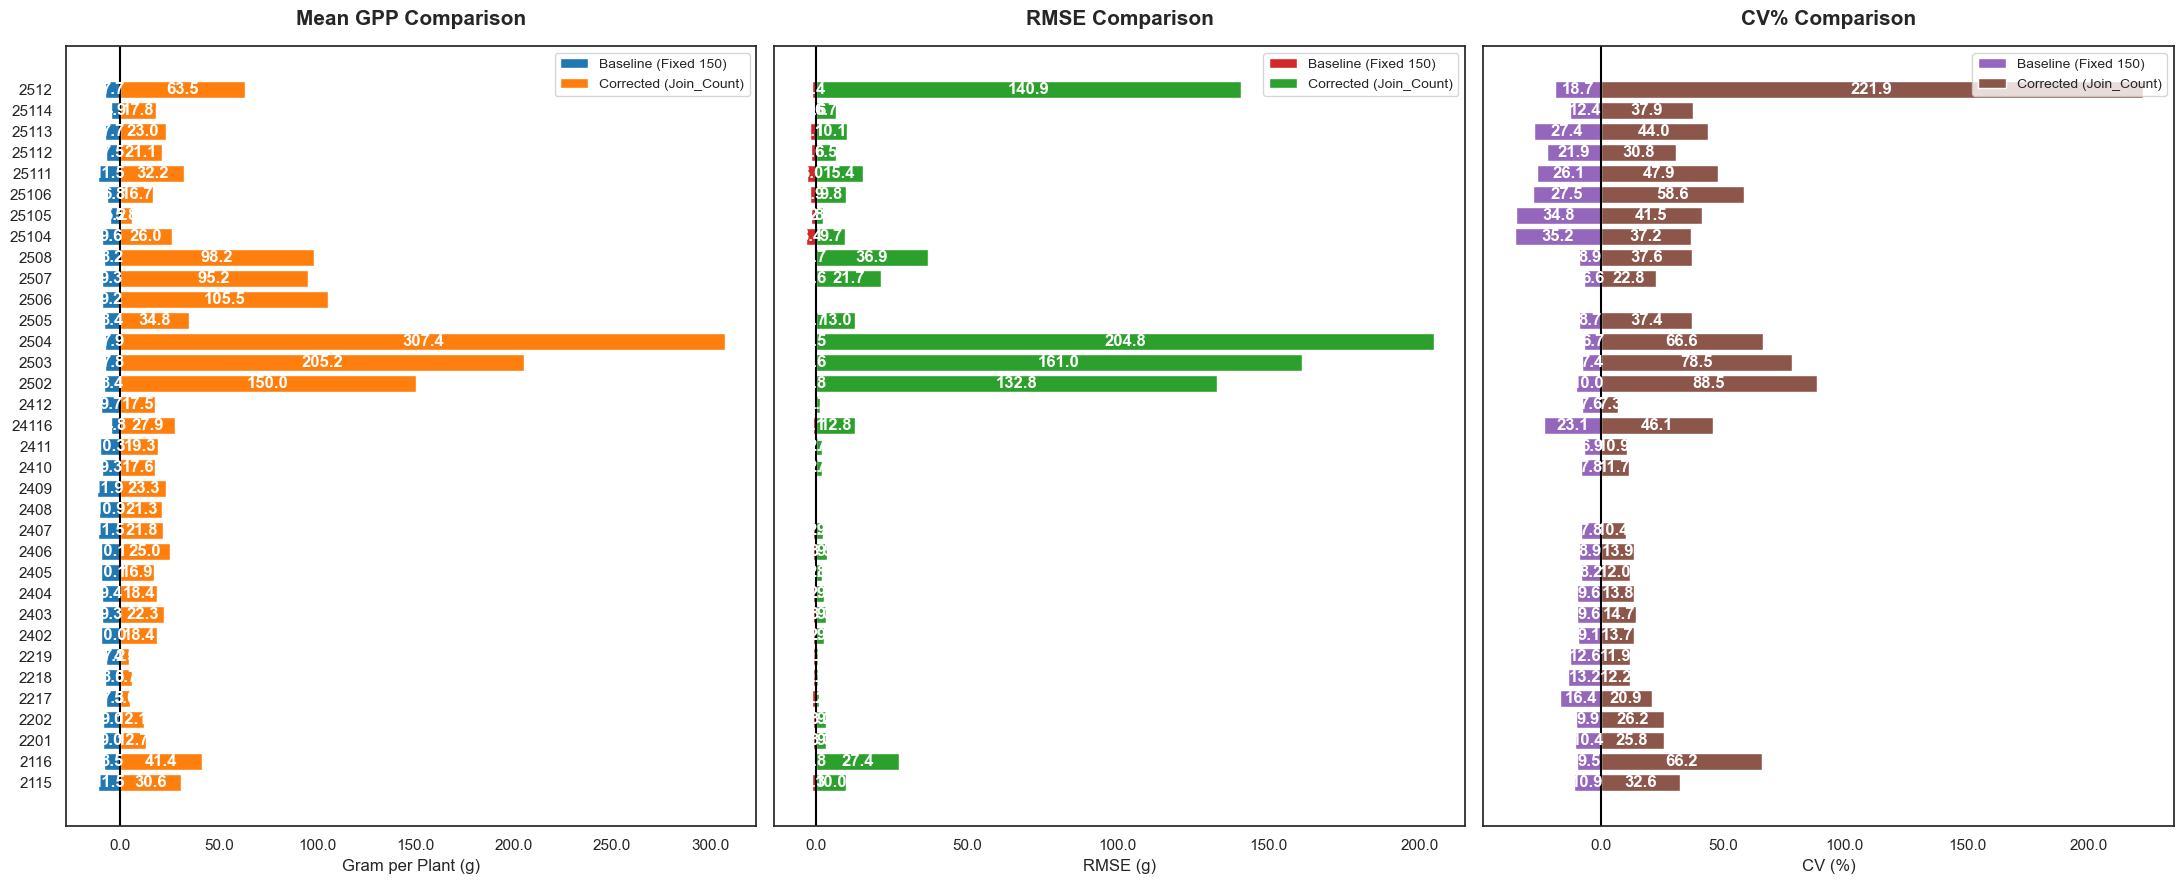

Analysis complete. GPP Metrics for 34 trials calculated and plotted.


In [9]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.ticker import FixedLocator

# Suppress technical warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)

# --- LOAD AND PREPARE DATA ---
file_path = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_kg_ha_updated.xlsx"
df = pd.read_excel(file_path)

# Standardize column names
df.columns = df.columns.str.strip()

# --- PRE-PROCESS GRAM PER PLANT DATA ---
# Baseline: divide by constant 150
df['GPP_Baseline'] = df['PLOTWT'] / 150

# Corrected: divide by Join_Count (handling zeros to avoid infinity)
df['Join_Count'] = df['Join_Count'].replace(0, np.nan)
df['GPP_Corrected'] = df['PLOTWT'] / df['Join_Count']

# Ensure categorical types for factors
for col in ['ENTRY', 'REP', 'IBLK', 'Experiment Name']:
    if col in df.columns:
        df[col] = df[col].astype(str)

def calculate_metrics(data, trait):
    """Calculates Mean, RMSE, and CV using consistent mixed model logic."""
    analysis_data = data.dropna(subset=[trait]).copy()
    if len(analysis_data) < 5: 
        return np.nan, np.nan, np.nan
    
    fixed_parts = ["C(ENTRY)"]
    if analysis_data['REP'].nunique() > 1:
        fixed_parts.append("C(REP)")
    formula = f"Q('{trait}') ~ " + " + ".join(fixed_parts)
    
    try:
        try:
            # Mixed Linear Model
            model = smf.mixedlm(formula, analysis_data, groups=analysis_data["REP"], re_formula="~0 + C(IBLK)")
            result = model.fit(method=["lbfgs"], maxiter=5000)
            mse = result.scale
        except:
            # Fallback to OLS
            ols_formula = f"Q('{trait}') ~ C(ENTRY) + C(REP)" if analysis_data['REP'].nunique() > 1 else f"Q('{trait}') ~ C(ENTRY)"
            ols_result = smf.ols(ols_formula, data=analysis_data).fit()
            mse = ols_result.mse_resid
            
        mean_val = analysis_data[trait].mean()
        rmse_val = np.sqrt(mse)
        cv_val = (rmse_val / mean_val) * 100
        return mean_val, rmse_val, cv_val
    except:
        return np.nan, np.nan, np.nan

# --- CALCULATION LOOP ---
results_list = []
for exp_name, exp_data in df.groupby('Experiment Name'):
    # Calculate for Baseline (GPP_Baseline)
    b_mean, b_rmse, b_cv = calculate_metrics(exp_data, 'GPP_Baseline')
    # Calculate for Corrected (GPP_Corrected)
    c_mean, c_rmse, c_cv = calculate_metrics(exp_data, 'GPP_Corrected')
    
    if np.isfinite([b_mean, c_mean]).all():
        results_list.append({
            'Trial': exp_name,
            'Baseline_Mean': b_mean, 'Corrected_Mean': c_mean,
            'Baseline_RMSE': b_rmse, 'Corrected_RMSE': c_rmse,
            'Baseline_CV': b_cv, 'Corrected_CV': c_cv
        })

results_df = pd.DataFrame(results_list)

# --- VISUALIZATION (TRIPLE PANEL TORNADO) ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 9), sharey=True)
sns.set_theme(style="white")

def plot_tornado(ax, left_data, right_data, left_label, right_label, title, unit, color_l, color_r, is_int=False):
    ax.barh(results_df['Trial'], -left_data, color=color_l, label=left_label)
    ax.barh(results_df['Trial'], right_data, color=color_r, label=right_label)
    ax.axvline(0, color='black', linewidth=1.5)
    ax.set_title(title, fontsize=15, pad=15, fontweight='bold')
    ax.set_xlabel(unit, fontsize=12)
    
    # Add labels inside bars
    for i, (l, r) in enumerate(zip(left_data, right_data)):
        fmt = ".0f" if is_int else ".1f"
        ax.text(-l/2, i, f"{l:{fmt}}", va='center', ha='center', color='white', fontweight='bold')
        ax.text(r/2, i, f"{r:{fmt}}", va='center', ha='center', color='white', fontweight='bold')
    
    # Fix X-axis ticks to show absolute values
    ticks = ax.get_xticks()
    ax.xaxis.set_major_locator(FixedLocator(ticks))
    ax.set_xticklabels([f"{abs(x):.1f}" for x in ticks])
    ax.legend(loc='upper right', fontsize=10)

# Panel 1: Mean
plot_tornado(ax1, results_df['Baseline_Mean'], results_df['Corrected_Mean'], 
             'Baseline (Fixed 150)', 'Corrected (Join_Count)', 'Mean GPP Comparison', 'Gram per Plant (g)', 
             '#1f77b4', '#ff7f0e', is_int=False)

# Panel 2: RMSE
plot_tornado(ax2, results_df['Baseline_RMSE'], results_df['Corrected_RMSE'], 
             'Baseline (Fixed 150)', 'Corrected (Join_Count)', 'RMSE Comparison', 'RMSE (g)', 
             '#d62728', '#2ca02c')

# Panel 3: CV%
plot_tornado(ax3, results_df['Baseline_CV'], results_df['Corrected_CV'], 
             'Baseline (Fixed 150)', 'Corrected (Join_Count)', 'CV% Comparison', 'CV (%)', 
             '#9467bd', '#8c564b')

plt.tight_layout()
plt.savefig('GPP_Performance_Tornado.png', dpi=300)
plt.show()

print(f"Analysis complete. GPP Metrics for {len(results_df)} trials calculated and plotted.")

C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 3.183166
  warnings.warn(msg, Con

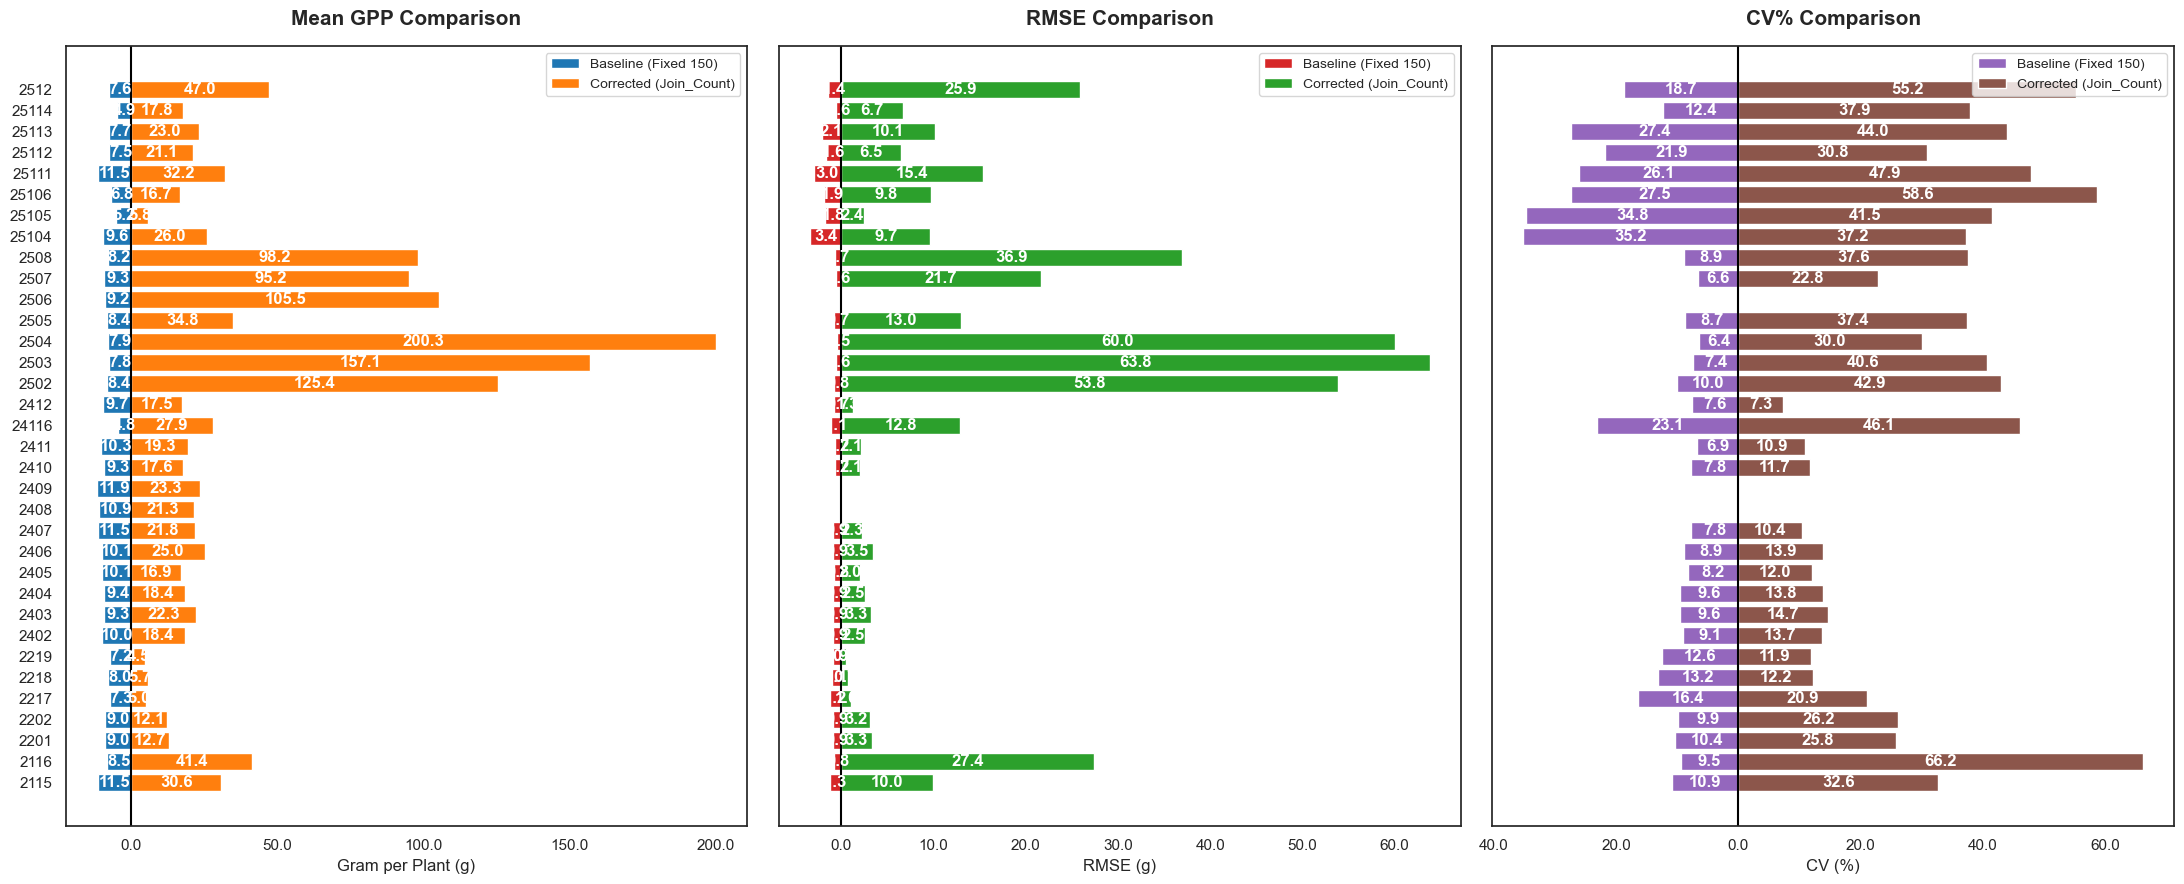

Analysis complete. Removed 25 outliers (>510 g/plant).


In [10]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.ticker import FixedLocator

# Suppress technical warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)

# --- LOAD AND PREPARE DATA ---
file_path = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_kg_ha_updated.xlsx"
df = pd.read_excel(file_path)

# Standardize column names
df.columns = df.columns.str.strip()

# --- PRE-PROCESS GRAM PER PLANT DATA ---
# Baseline: divide by constant 150
df['GPP_Baseline'] = df['PLOTWT'] / 150

# Corrected: divide by Join_Count (handling zeros to avoid infinity)
df['Join_Count'] = df['Join_Count'].replace(0, np.nan)
df['GPP_Corrected'] = df['PLOTWT'] / df['Join_Count']

# --- OUTLIER REMOVAL (NON-DESTRUCTIVE) ---
# Filter out values > 510. This creates a new object for analysis 
# without touching the 'df' variable loaded from Excel.
df_filtered = df[df['GPP_Corrected'] <= 510].copy()

# Ensure categorical types for factors on the filtered set
for col in ['ENTRY', 'REP', 'IBLK', 'Experiment Name']:
    if col in df_filtered.columns:
        df_filtered[col] = df_filtered[col].astype(str)

def calculate_metrics(data, trait):
    """Calculates Mean, RMSE, and CV using consistent mixed model logic."""
    analysis_data = data.dropna(subset=[trait]).copy()
    if len(analysis_data) < 5: 
        return np.nan, np.nan, np.nan
    
    fixed_parts = ["C(ENTRY)"]
    if analysis_data['REP'].nunique() > 1:
        fixed_parts.append("C(REP)")
    formula = f"Q('{trait}') ~ " + " + ".join(fixed_parts)
    
    try:
        try:
            # Mixed Linear Model
            model = smf.mixedlm(formula, analysis_data, groups=analysis_data["REP"], re_formula="~0 + C(IBLK)")
            result = model.fit(method=["lbfgs"], maxiter=5000)
            mse = result.scale
        except:
            # Fallback to OLS
            ols_formula = f"Q('{trait}') ~ C(ENTRY) + C(REP)" if analysis_data['REP'].nunique() > 1 else f"Q('{trait}') ~ C(ENTRY)"
            ols_result = smf.ols(ols_formula, data=analysis_data).fit()
            mse = ols_result.mse_resid
            
        mean_val = analysis_data[trait].mean()
        rmse_val = np.sqrt(mse)
        cv_val = (rmse_val / mean_val) * 100
        return mean_val, rmse_val, cv_val
    except:
        return np.nan, np.nan, np.nan

# --- CALCULATION LOOP (Using df_filtered) ---
results_list = []
for exp_name, exp_data in df_filtered.groupby('Experiment Name'):
    # Calculate for Baseline (GPP_Baseline)
    b_mean, b_rmse, b_cv = calculate_metrics(exp_data, 'GPP_Baseline')
    # Calculate for Corrected (GPP_Corrected)
    c_mean, c_rmse, c_cv = calculate_metrics(exp_data, 'GPP_Corrected')
    
    if np.isfinite([b_mean, c_mean]).all():
        results_list.append({
            'Trial': exp_name,
            'Baseline_Mean': b_mean, 'Corrected_Mean': c_mean,
            'Baseline_RMSE': b_rmse, 'Corrected_RMSE': c_rmse,
            'Baseline_CV': b_cv, 'Corrected_CV': c_cv
        })

results_df = pd.DataFrame(results_list)

# --- VISUALIZATION (TRIPLE PANEL TORNADO) ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 9), sharey=True)
sns.set_theme(style="white")

def plot_tornado(ax, left_data, right_data, left_label, right_label, title, unit, color_l, color_r, is_int=False):
    ax.barh(results_df['Trial'], -left_data, color=color_l, label=left_label)
    ax.barh(results_df['Trial'], right_data, color=color_r, label=right_label)
    ax.axvline(0, color='black', linewidth=1.5)
    ax.set_title(title, fontsize=15, pad=15, fontweight='bold')
    ax.set_xlabel(unit, fontsize=12)
    
    for i, (l, r) in enumerate(zip(left_data, right_data)):
        fmt = ".0f" if is_int else ".1f"
        ax.text(-l/2, i, f"{l:{fmt}}", va='center', ha='center', color='white', fontweight='bold')
        ax.text(r/2, i, f"{r:{fmt}}", va='center', ha='center', color='white', fontweight='bold')
    
    ticks = ax.get_xticks()
    ax.xaxis.set_major_locator(FixedLocator(ticks))
    ax.set_xticklabels([f"{abs(x):.1f}" for x in ticks])
    ax.legend(loc='upper right', fontsize=10)

plot_tornado(ax1, results_df['Baseline_Mean'], results_df['Corrected_Mean'], 
             'Baseline (Fixed 150)', 'Corrected (Join_Count)', 'Mean GPP Comparison', 'Gram per Plant (g)', 
             '#1f77b4', '#ff7f0e', is_int=False)

plot_tornado(ax2, results_df['Baseline_RMSE'], results_df['Corrected_RMSE'], 
             'Baseline (Fixed 150)', 'Corrected (Join_Count)', 'RMSE Comparison', 'RMSE (g)', 
             '#d62728', '#2ca02c')

plot_tornado(ax3, results_df['Baseline_CV'], results_df['Corrected_CV'], 
             'Baseline (Fixed 150)', 'Corrected (Join_Count)', 'CV% Comparison', 'CV (%)', 
             '#9467bd', '#8c564b')

plt.tight_layout()
plt.savefig('GPP_Filtered_Tornado.png', dpi=300)
plt.show()

removed_count = len(df) - len(df_filtered)
print(f"Analysis complete. Removed {removed_count} outliers (>510 g/plant).")

In [ ]:
# every join count>150 equal to 150

C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 3.183166
  warnings.warn(msg, Con

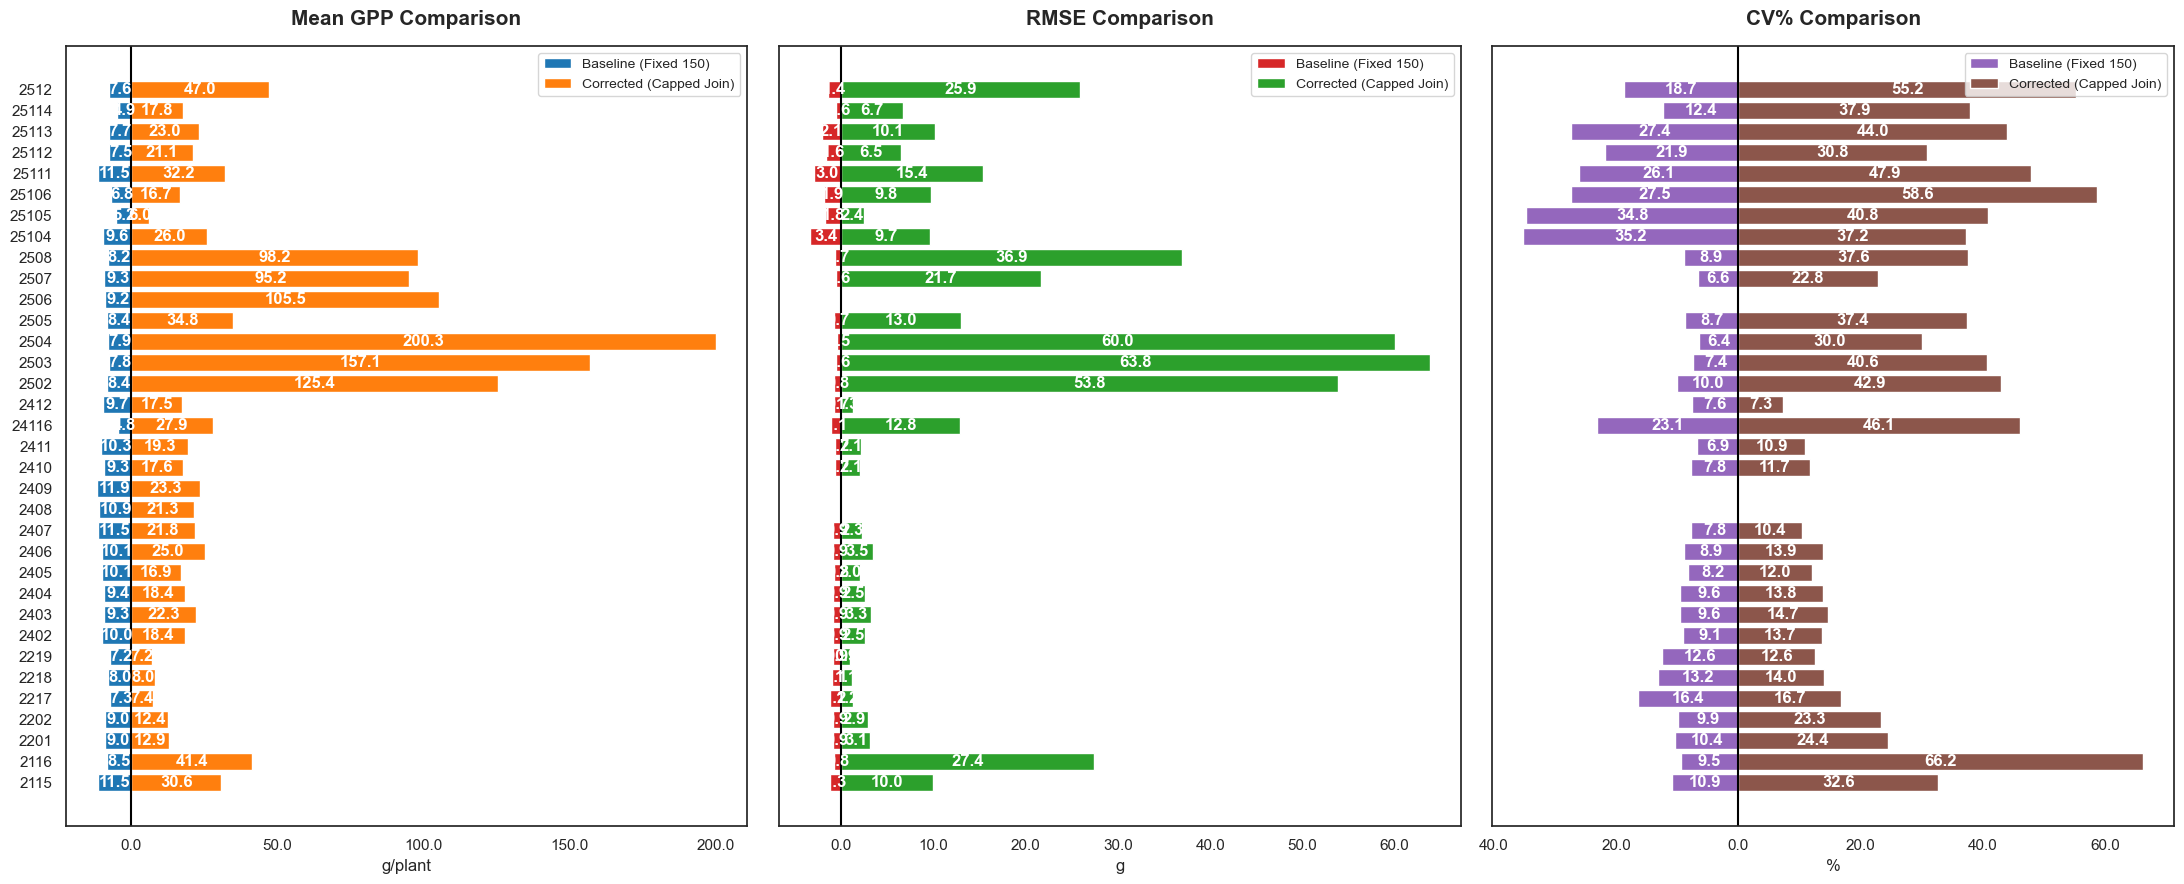

Analysis complete. Removed 25 outliers.


In [12]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.ticker import FixedLocator

# Suppress technical warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)

# --- LOAD AND PREPARE DATA ---
file_path = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_kg_ha_updated.xlsx"
df = pd.read_excel(file_path)

# Standardize column names
df.columns = df.columns.str.strip()

# --- PRE-PROCESS GRAM PER PLANT DATA ---
df['GPP_Baseline'] = df['PLOTWT'] / 150
df['Join_Count'] = df['Join_Count'].replace(0, np.nan)
df['GPP_Corrected'] = df['PLOTWT'] / df['Join_Count']

# --- DATA CLEANING & CAPPING (NON-DESTRUCTIVE) ---
df_filtered = df[df['GPP_Corrected'] <= 510].copy()
df_filtered['Join_Count'] = df_filtered['Join_Count'].clip(upper=150)
df_filtered['GPP_Corrected'] = df_filtered['PLOTWT'] / df_filtered['Join_Count']

for col in ['ENTRY', 'REP', 'IBLK', 'Experiment Name']:
    if col in df_filtered.columns:
        df_filtered[col] = df_filtered[col].astype(str)

def calculate_metrics(data, trait):
    """Calculates Mean, RMSE, and CV using consistent mixed model logic."""
    analysis_data = data.dropna(subset=[trait]).copy()
    if len(analysis_data) < 5: 
        return np.nan, np.nan, np.nan
    
    fixed_parts = ["C(ENTRY)"]
    if analysis_data['REP'].nunique() > 1:
        fixed_parts.append("C(REP)")
    formula = f"Q('{trait}') ~ " + " + ".join(fixed_parts)
    
    try:
        try:
            model = smf.mixedlm(formula, analysis_data, groups=analysis_data["REP"], re_formula="~0 + C(IBLK)")
            result = model.fit(method=["lbfgs"], maxiter=5000)
            mse = result.scale
        except:
            ols_formula = f"Q('{trait}') ~ C(ENTRY) + C(REP)" if analysis_data['REP'].nunique() > 1 else f"Q('{trait}') ~ C(ENTRY)"
            ols_result = smf.ols(ols_formula, data=analysis_data).fit()
            mse = ols_result.mse_resid
            
        mean_val = analysis_data[trait].mean()
        rmse_val = np.sqrt(mse)
        cv_val = (rmse_val / mean_val) * 100
        return mean_val, rmse_val, cv_val
    except:
        return np.nan, np.nan, np.nan

# --- CALCULATION LOOP ---
results_list = []
for exp_name, exp_data in df_filtered.groupby('Experiment Name'):
    b_mean, b_rmse, b_cv = calculate_metrics(exp_data, 'GPP_Baseline')
    c_mean, c_rmse, c_cv = calculate_metrics(exp_data, 'GPP_Corrected')
    
    if np.isfinite([b_mean, c_mean]).all():
        results_list.append({
            'Trial': exp_name,
            'Baseline_Mean': b_mean, 'Corrected_Mean': c_mean,
            'Baseline_RMSE': b_rmse, 'Corrected_RMSE': c_rmse,
            'Baseline_CV': b_cv, 'Corrected_CV': c_cv
        })

results_df = pd.DataFrame(results_list)

# --- VISUALIZATION ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 9), sharey=True)
sns.set_theme(style="white")

def plot_tornado(ax, left_data, right_data, left_label, right_label, title, unit, color_l, color_r):
    ax.barh(results_df['Trial'], -left_data, color=color_l, label=left_label)
    ax.barh(results_df['Trial'], right_data, color=color_r, label=right_label)
    ax.axvline(0, color='black', linewidth=1.5)
    ax.set_title(title, fontsize=15, pad=15, fontweight='bold')
    ax.set_xlabel(unit, fontsize=12)
    
    for i, (l, r) in enumerate(zip(left_data, right_data)):
        ax.text(-l/2, i, f"{l:.1f}", va='center', ha='center', color='white', fontweight='bold')
        ax.text(r/2, i, f"{r:.1f}", va='center', ha='center', color='white', fontweight='bold')
    
    ticks = ax.get_xticks()
    ax.xaxis.set_major_locator(FixedLocator(ticks))
    ax.set_xticklabels([f"{abs(x):.1f}" for x in ticks])
    ax.legend(loc='upper right', fontsize=10)

# FIXED CALLS: Added color hex codes as arguments 8 and 9
plot_tornado(ax1, results_df['Baseline_Mean'], results_df['Corrected_Mean'], 
             'Baseline (Fixed 150)', 'Corrected (Capped Join)', 'Mean GPP Comparison', 'g/plant',
             '#1f77b4', '#ff7f0e')

plot_tornado(ax2, results_df['Baseline_RMSE'], results_df['Corrected_RMSE'], 
             'Baseline (Fixed 150)', 'Corrected (Capped Join)', 'RMSE Comparison', 'g',
             '#d62728', '#2ca02c')

plot_tornado(ax3, results_df['Baseline_CV'], results_df['Corrected_CV'], 
             'Baseline (Fixed 150)', 'Corrected (Capped Join)', 'CV% Comparison', '%',
             '#9467bd', '#8c564b')

plt.tight_layout()
plt.savefig('GPP_Capped_Analysis.png', dpi=350)
plt.show()

print(f"Analysis complete. Removed {len(df) - len(df_filtered)} outliers.")